In [3]:
import requests
import time
import random
import json
import pandas as pd
from bs4 import BeautifulSoup
import re
import numpy as np

In [ ]:
#uvicoz,neutogena

In [ ]:
#DOjaWF gdgoEp.cPHDOP col-12-12._75nlfW.slAVV4.DMMoT0.hl05eU.UkUFwK

In [2]:
names = []
quantity = []
rating = []
soldcount = []
prices = []
discount = []
dic=[]
for i in range(1,16):
    url="https://www.flipkart.com/search?q=sunscreen&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page="+str(i)
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                      "(KHTML, like Gecko) Chrome/141.0.0.0 Safari/537.36"
    }
    page=requests.get(url,headers=headers)
    soup=BeautifulSoup(page.text)
    n=soup.find_all("a", class_="wjcEIp")
    #names=[]
    for i in n:
        names.append(i.text.split("Sunscreen")[0])
    #names
    g=soup.find_all("div",class_="NqpwHC")
    #quantity=[]
    for i in g:
        quantity.append(i.text)
    #quantity
    r=soup.find_all("span",class_="Y1HWO0")
    parentr=soup.find_all("div",class_="slAVV4")
    childr=soup.find_all("div",class_="_5OesEi afFzxY")
    #rating=[]
    for i in r:
            rating.append(i.text)
    
    #len(rating)
    s=soup.find_all("span",class_="Wphh3N")
    #soldcount = []


    for i in s:  # assuming s is a list of elements
            text = i.text
            # Find all sequences of digits and commas
            matches = re.findall(r'[\d,]+', text)
            for num in matches:
                # Remove commas and convert to int
                soldcount.append(int(num.replace(',', '')))
    #print(soldcount)
    p= soup.find_all(
    "div",
    class_=lambda x: x and "Nx9bqj" in x and "OQ4U3k" not in x)
    #prices=[]
    notp=soup.find_all("div",class_="Nx9bqj OQ4U3k")
    for i in p:
        if i:
            if(i not in notp):
                prices.append(i.text)
        else:
            prices.append(np.nan)
    #notp
    d=soup.find_all("div",class_="UkUFwK")
    notd=soup.find_all("div",class_="UkUFwK WMQHm1")
    box = soup.find("div", class_="DOjaWF gdgoEp")

    if box:  # main container exists
        product_slots = box.find_all("div", class_="hl05eU")  # adjust to product card

        for slot in product_slots:
        # Look for discount specifically
            discount_tag = slot.find("div", class_="UkUFwK")  # typical discount class on Flipkart
            if discount_tag and discount_tag.text:
                    dic.append(re.findall(r"(\d+)%\s*off",discount_tag.text))
                
            else:
                dic.append(0)  # no discount tag found

    else:
        dic.append(np.nan)


    
    #print(f"Page {page_num}, Total items collected: {len(dic)}")

#print(f"\nFinal results: {len(dic)} items")
#for i, item in enumerate(dic, 1):
    #print(f"{i}: {item}")
    print(f"Page {page_num}: Names={len(names)}, Quantity={len(quantity)}, Rating={len(rating)}, SoldCount={len(soldcount)}, Prices={len(prices)}, Discount={len(dic)}")


NameError: name 'page_num' is not defined

In [97]:
for i in range(len(names)):
    if(names[i]== "TLC 365 " or names[i]== "Actiwow " or names[i]== "SEEKCAUS " or names[i]== "vanaura " or  names[i]== "360 Block "):
        print(i)

138
339
353


In [98]:
import numpy as np

inx = [138,
339,
353
]

for i in inx:
    if i < len(names):  # to avoid index out of range
        names[i] = np.nan
print(len(names))

600


In [99]:
import numpy as np
nan_indices = [i for i, x in enumerate(names) if x is np.nan]
print(nan_indices)

[138, 339, 353]


In [100]:
inx =[138, 339, 353]
for i in inx:
    if i<len(rating):
        rating.insert(i,np.nan)
print(len(rating))


600


In [101]:
inx=[138, 339, 353]
for i in inx:
    if i<len(soldcount):
        soldcount.insert(i,np.nan)
print(len(soldcount))

600


In [102]:
print(len(names))
print(len(quantity))
print(len(rating))
print(len(soldcount))
print(len(prices))
print(len(dic))

600
600
600
600
600
600


In [3]:
d={"Brand":names,"Quantity":quantity,"Rating":rating,"Customer count":soldcount,"cost":prices,"discount %":dic}

NameError: name 'names' is not defined

In [104]:
df=pd.DataFrame(d)

In [105]:
import pandas as pd

# Suppose your DataFrame is called df
df.to_csv("edaproject.csv", index=False)

In [106]:
df

,Brand,Quantity,Rating,Customer count,cost,discount %
0,Dot & Key,50 g,4.4,21129.0,₹396,[11]
1,The Derma Co,50 g,4.4,74296.0,₹415,[16]
2,Dermatouch,30 g,4.1,92581.0,₹94,[52]
3,Reginald Men,15 g,4,4861.0,₹294,[34]
4,Dot & Key,30 g,4.2,13655.0,₹255,[14]
...,...,...,...,...,...,...
595,POND's,14 ml,4.2,2214.0,₹179,[40]
596,Lakmé,50 ml,4.2,30178.0,₹176,[41]
597,Nutriglow Advanced Organics,100 g,3.9,9462.0,₹142,[66]
598,Oriflame,50 ml,4.3,242.0,₹774,[13]


## TYPE CASTING

In [107]:
df.describe

<bound method NDFrame.describe of                             Brand Quantity Rating  Customer count  cost  \
0                      Dot & Key      50 g    4.4         21129.0  ₹396   
1                   The Derma Co      50 g    4.4         74296.0  ₹415   
2                     Dermatouch      30 g    4.1         92581.0   ₹94   
3                   Reginald Men      15 g      4          4861.0  ₹294   
4                      Dot & Key      30 g    4.2         13655.0  ₹255   
..                            ...      ...    ...             ...   ...   
595                       POND's     14 ml    4.2          2214.0  ₹179   
596                        Lakmé     50 ml    4.2         30178.0  ₹176   
597  Nutriglow Advanced Organics     100 g    3.9          9462.0  ₹142   
598                     Oriflame     50 ml    4.3           242.0  ₹774   
599                      HAPPIER     50 ml    4.4            56.0  ₹535   

    discount %  
0         [11]  
1         [16]  
2         [52]

In [109]:
df.head(5)

,Brand,Quantity,Rating,Customer count,cost,discount %
0,Dot & Key,50 g,4.4,21129.0,₹396,[11]
1,The Derma Co,50 g,4.4,74296.0,₹415,[16]
2,Dermatouch,30 g,4.1,92581.0,₹94,[52]
3,Reginald Men,15 g,4,4861.0,₹294,[34]
4,Dot & Key,30 g,4.2,13655.0,₹255,[14]


In [110]:

df['discount %'] = df['discount %'].apply(lambda x: int(x[0]) if isinstance(x, list) and len(x) > 0 else np.nan)


In [111]:
df.head(5)

,Brand,Quantity,Rating,Customer count,cost,discount %
0,Dot & Key,50 g,4.4,21129.0,₹396,11.0
1,The Derma Co,50 g,4.4,74296.0,₹415,16.0
2,Dermatouch,30 g,4.1,92581.0,₹94,52.0
3,Reginald Men,15 g,4,4861.0,₹294,34.0
4,Dot & Key,30 g,4.2,13655.0,₹255,14.0


In [113]:
df['cost'] = df['cost'].replace('[₹,]', '', regex=True).astype(float)


In [115]:
df['Quantity'] = df['Quantity'].str.extract(r'(\d+\.?\d*)').astype(float)

In [116]:
df['Rating'] = df['Rating'].astype(float)

In [119]:
df['Customer count'] = df['Customer count'].fillna(0).astype(int)


In [120]:
df['Customer count'] = df['Customer count'].astype(int)

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           597 non-null    object 
 1   Quantity        600 non-null    float64
 2   Rating          597 non-null    float64
 3   Customer count  600 non-null    int32  
 4   cost            600 non-null    float64
 5   discount %      586 non-null    float64
dtypes: float64(4), int32(1), object(1)
memory usage: 25.9+ KB


In [122]:
df

,Brand,Quantity,Rating,Customer count,cost,discount %
0,Dot & Key,50.0,4.4,21129,396.0,11.0
1,The Derma Co,50.0,4.4,74296,415.0,16.0
2,Dermatouch,30.0,4.1,92581,94.0,52.0
3,Reginald Men,15.0,4.0,4861,294.0,34.0
4,Dot & Key,30.0,4.2,13655,255.0,14.0
...,...,...,...,...,...,...
595,POND's,14.0,4.2,2214,179.0,40.0
596,Lakmé,50.0,4.2,30178,176.0,41.0
597,Nutriglow Advanced Organics,100.0,3.9,9462,142.0,66.0
598,Oriflame,50.0,4.3,242,774.0,13.0


## UNIVARIATE ANALYSIS

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (8, 4)

In [2]:
df.head(5)

NameError: name 'df' is not defined

In [125]:
df.shape

(600, 6)

### countplot

In [126]:
df["Brand"].value_counts()

Brand
Fixderma           32
BIOTIQUE           30
Lakmé              26
The Derma Co       24
Lacto Calamine     22
                   ..
Undry               1
Hydrasun            1
Rivela              1
PROWL               1
Riyo Herbs          1
Name: count, Length: 164, dtype: int64

In [144]:
df["Brand"].unique()

array(['Dot & Key ', 'The Derma Co ', 'Dermatouch ', 'Reginald\xa0Men ',
       'Lacto Calamine ', 'Mamaearth ', 'deconstruct ', "Dr. Sheth's ",
       'Conscious Chemist ', 'Minimalist ', 'Aqualogica ', 'BIOTIQUE ',
       'NEUTROGENA ', 'Foxtale ', "Re'equil ", 'Lakmé ', 'La Shield ',
       'Cetaphil ', 'Pilgrim ', 'NutriGlow ', 'Fixderma ', 'HYPHEN ',
       'BELLAVITA ', "POND's ", 'Reginald Men ', 'GARNIER ',
       'Nutriglow Advanced Organics ', 'The Plant Fix Plix ', 'Joy ',
       'UNDERATED ', 'ELIBLISS ', 'Aroma Magic ', 'Zydus Cadila ',
       'VLCC ', 'UVSMART ', 'SunScoop ', 'Kanpeki ',
       'KEYA SETH AROMATHERAPY ', 'AROMA TREASURES ', 'SUNHALT ',
       'Newsio ', 'Elemnt Sports Science ', 'COLORBAR ', 'SUNSTOP ',
       'RAAGA PROFESSIONAL ', 'LOTUS HERBALS ', 'solasafe ', nan,
       "NutriGlow NATURAL'S ", 'Mother Sparsh ', 'Heliocare ', 'MFine ',
       "The Soumi's Can Product ", 'Ray Back ', 'FAIR INSTA ',
       'KLM LABORATORIES ', 'Ekran Aqua ', 'WishCare '

In [145]:
df["Brand"].nunique()

164

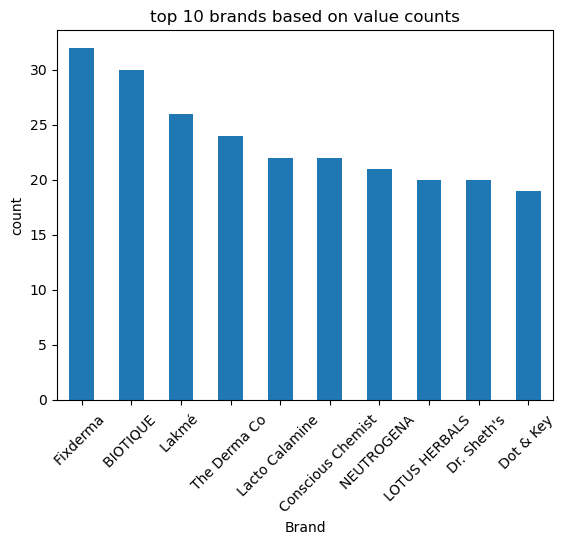

In [155]:
#using matplotlib
df["Brand"].value_counts().iloc[:10].plot.bar()
plt.ylabel("count")
plt.xticks(rotation=45)
plt.title("top 10 brands based on value counts")
plt.show()

C:\Users\jessi\AppData\Local\Temp\ipykernel_18388\1277880428.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Brand",data=topdf,order=top_brands,palette=colors)
C:\Users\jessi\AppData\Local\Temp\ipykernel_18388\1277880428.py:8: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.countplot(x="Brand",data=topdf,order=top_brands,palette=colors)


<Axes: title={'center': 'top 5 brands based on value counts'}, xlabel='Brand', ylabel='count'>

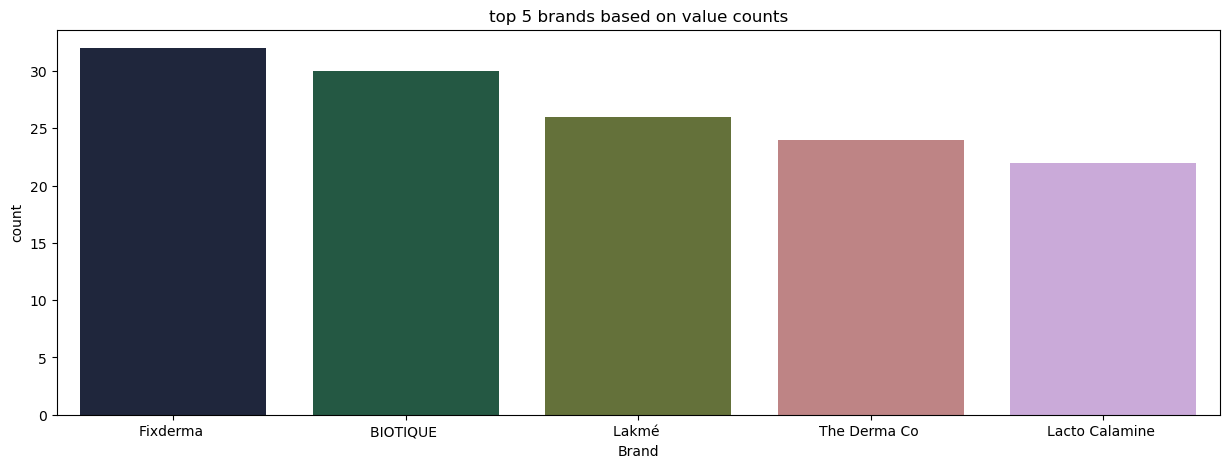

In [158]:
#using sns
#top 10 brands based on value counts
top_brands = df['Brand'].value_counts().head(5).index
topdf=df[df["Brand"].isin(top_brands)]
plt.figure(figsize=(15,5))
plt.title("top 5 brands based on value counts")
colors=sns.color_palette("cubehelix")
sns.countplot(x="Brand",data=topdf,order=top_brands,palette=colors)

